In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sber_data = pd.read_csv('sber_data.csv')
sber_data.head()

,id,full_sq,life_sq,floor,sub_area,preschool_quota,preschool_education_centers_raion,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,...,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,theater_km,museum_km,ecology,mosque_count_1000,price_doc
0,1,43,27.0,4.0,Bibirevo,5001.0,5,11065.0,5,0,...,0.637189,0.947962,0.177975,0.625783,0.628187,14.053047,7.389498,good,0,5850000
1,2,34,19.0,3.0,Nagatinskij Zaton,3119.0,5,6237.0,8,0,...,0.688796,1.072315,0.273345,0.967821,0.471447,6.829889,0.709260,excellent,0,6000000
2,3,43,29.0,2.0,Tekstil'shhiki,1463.0,4,5580.0,7,0,...,1.543049,0.391957,0.158072,3.178751,0.755946,4.273200,3.156423,poor,0,5700000
3,4,89,50.0,9.0,Mitino,6839.0,9,17063.0,10,0,...,0.934273,0.892674,0.236455,1.031777,1.561505,16.990677,16.041521,good,0,13100000
4,5,77,77.0,4.0,Basmannoe,3240.0,7,7770.0,9,0,...,0.077901,0.810801,0.376838,0.378756,0.121681,1.112486,1.800125,excellent,0,16331452


In [4]:
display(sber_data.tail())

,id,full_sq,life_sq,floor,sub_area,preschool_quota,preschool_education_centers_raion,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,...,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,theater_km,museum_km,ecology,mosque_count_1000,price_doc
30466,30469,44,27.0,7.0,Otradnoe,5088.0,4,12721.0,4,0,...,1.103579,0.167718,0.349899,1.235066,0.612359,7.482165,4.836787,good,0,7400000
30467,30470,86,59.0,3.0,Tverskoe,1874.0,4,6772.0,4,1,...,0.069986,0.086552,0.362681,0.850385,0.310021,0.778428,1.450108,poor,0,25000000
30468,30471,45,NaN,10.0,Poselenie Vnukovskoe,NaN,0,NaN,0,0,...,4.338453,1.339078,1.234235,1.192543,1.186621,13.459593,9.890758,no data,0,6970959
30469,30472,64,32.0,5.0,Obruchevskoe,2372.0,6,6083.0,8,0,...,1.204798,1.340017,0.130667,1.644053,0.476021,2.088193,4.119706,satisfactory,0,13500000
30470,30473,43,28.0,1.0,Novogireevo,2215.0,4,5824.0,4,0,...,2.108265,0.825811,0.378950,0.480531,0.867332,0.688707,0.127867,poor,0,5600000


In [5]:
display(sber_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Data columns (total 61 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     30471 non-null  int64  
 1   full_sq                                30471 non-null  int64  
 2   life_sq                                24088 non-null  float64
 3   floor                                  30304 non-null  float64
 4   sub_area                               30471 non-null  str    
 5   preschool_quota                        23783 non-null  float64
 6   preschool_education_centers_raion      30471 non-null  int64  
 7   school_quota                           23786 non-null  float64
 8   school_education_centers_raion         30471 non-null  int64  
 9   school_education_centers_top_20_raion  30471 non-null  int64  
 10  hospital_beds_raion                    16030 non-null  float64
 11  healthcare_ce

None

In [9]:
# Способ 1: Количество уникальных значений
num_districts = sber_data['sub_area'].nunique()
print(f"Количество районов: {num_districts}")

# Способ 2: Получить список уникальных районов
unique_districts = sber_data['sub_area'].unique()
print(f"Список районов: {unique_districts}")
print(f"Количество районов: {len(unique_districts)}")

# Способ 3: Подробная статистика
print(sber_data['sub_area'].value_counts())

Количество районов: 146
Список районов: <StringArray>
[                      'Bibirevo',              'Nagatinskij Zaton',
                 'Tekstil'shhiki',                         'Mitino',
                      'Basmannoe',                 'Nizhegorodskoe',
                     'Sokol'niki',                        'Koptevo',
                        'Kuncevo',               'Kosino-Uhtomskoe',
 ...
           'Poselenie Kokoshkino',                     'Vostochnoe',
      'Poselenie Krasnopahorskoe',      'Poselenie Novofedorovskoe',
          'Poselenie Voronovskoe',           'Poselenie Klenovskoe',
            'Poselenie Rogovskoe',             'Poselenie Kievskij',
                'Molzhaninovskoe', 'Poselenie Mihajlovo-Jarcevskoe']
Length: 146, dtype: str
Количество районов: 146
sub_area
Poselenie Sosenskoe               1776
Nekrasovka                        1611
Poselenie Vnukovskoe              1372
Poselenie Moskovskij               925
Poselenie Voskresenskoe            713

In [10]:
# Максимальная цена
max_price = sber_data['price_doc'].max()
print(f"Максимальная цена квартир: {max_price}")

Максимальная цена квартир: 111111112


C:\Users\sergi\AppData\Local\Temp\ipykernel_3564\3427617855.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sber_data, x='ecology', y='price_doc', order=ecology_order,


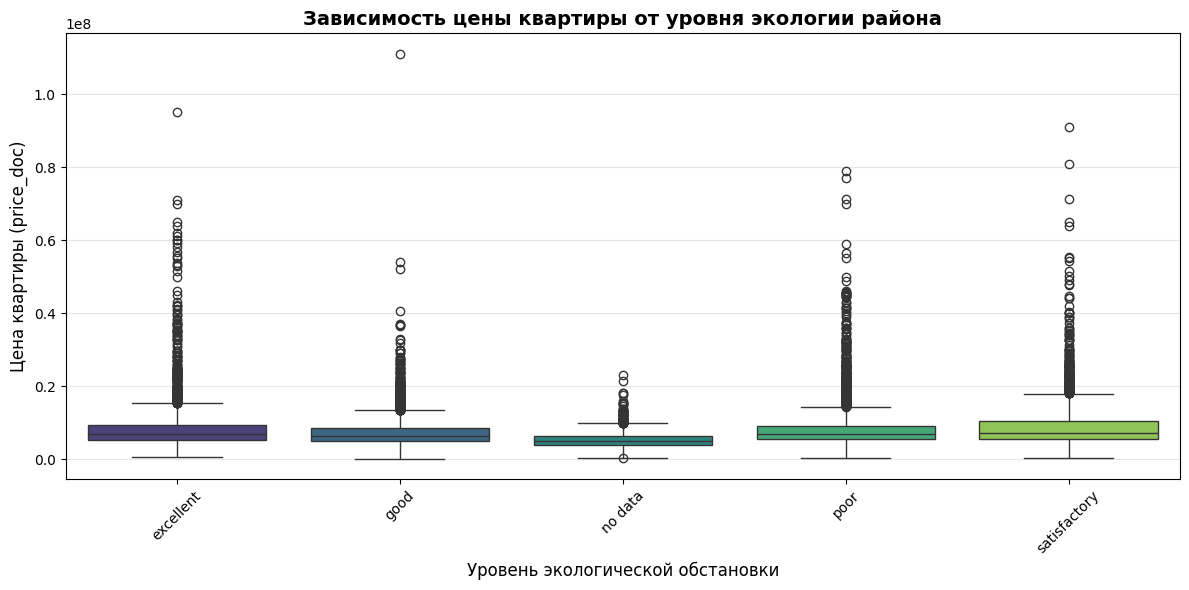

СТАТИСТИКА ЦЕН ПО УРОВНЯМ ЭКОЛОГИИ
              count     mean     median     min        max
ecology                                                   
excellent      3938  8201252  6750000.0  500000   95122496
good           7174  7082094  6415200.0  100000  111111112
no data        7656  5241629  5000675.0  200000   23000000
poor           8018  7747995  6774500.0  190000   78802248
satisfactory   3685  8599506  7200000.0  360000   91066096

МЕДИАННЫЕ ЦЕНЫ ПО УРОВНЯМ ЭКОЛОГИИ
no data: 5,000,675
good: 6,415,200
excellent: 6,750,000
poor: 6,774,500
satisfactory: 7,200,000

ОТВЕТ НА ВОПРОС
Уровень экологической обстановки, который ценится на рынке меньше всего: no data
Медианная цена при этом уровне: 5,000,675


C:\Users\sergi\AppData\Local\Temp\ipykernel_3564\3427617855.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sber_data, x='ecology', y='price_doc', order=ecology_order,


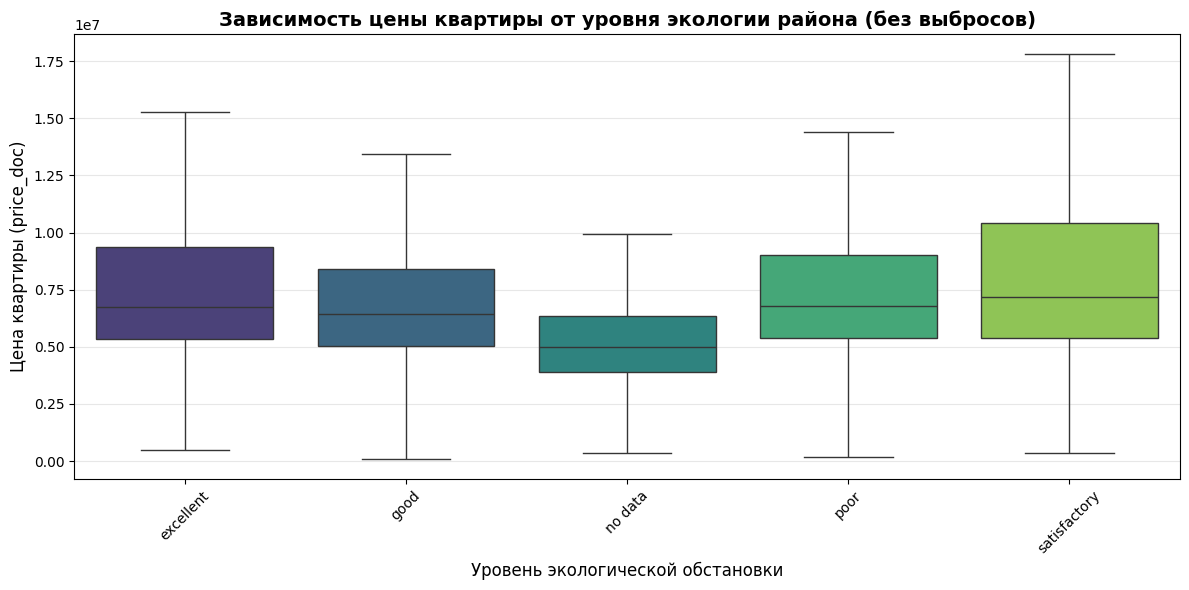

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
sber_data = pd.read_csv('sber_data.csv')

# Построение коробчатой диаграммы
plt.figure(figsize=(12, 6))

# Сортировка уровней экологии для лучшего отображения
ecology_order = sorted(sber_data['ecology'].dropna().unique())

# Boxplot
sns.boxplot(data=sber_data, x='ecology', y='price_doc', order=ecology_order, 
            palette='viridis')

plt.title('Зависимость цены квартиры от уровня экологии района', fontsize=14, fontweight='bold')
plt.xlabel('Уровень экологической обстановки', fontsize=12)
plt.ylabel('Цена квартиры (price_doc)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная статистика для анализа
print("="*60)
print("СТАТИСТИКА ЦЕН ПО УРОВНЯМ ЭКОЛОГИИ")
print("="*60)

ecology_stats = sber_data.groupby('ecology')['price_doc'].agg(['count', 'mean', 'median', 'min', 'max'])
ecology_stats['mean'] = ecology_stats['mean'].astype(int)
print(ecology_stats)

print("\n" + "="*60)
print("МЕДИАННЫЕ ЦЕНЫ ПО УРОВНЯМ ЭКОЛОГИИ")
print("="*60)

median_prices = sber_data.groupby('ecology')['price_doc'].median().sort_values()
for ecology, price in median_prices.items():
    print(f"{ecology}: {price:,.0f}")

# Определяем уровень с наименьшей ценой
min_price_level = median_prices.index[0]
min_price_value = median_prices.iloc[0]

print("\n" + "="*60)
print("ОТВЕТ НА ВОПРОС")
print("="*60)
print(f"Уровень экологической обстановки, который ценится на рынке меньше всего: {min_price_level}")
print(f"Медианная цена при этом уровне: {min_price_value:,.0f}")

# Альтернативный вариант - без выбросов для лучшей читаемости
plt.figure(figsize=(12, 6))
sns.boxplot(data=sber_data, x='ecology', y='price_doc', order=ecology_order,
            palette='viridis', showfliers=False)  # без выбросов
plt.title('Зависимость цены квартиры от уровня экологии района (без выбросов)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Уровень экологической обстановки', fontsize=12)
plt.ylabel('Цена квартиры (price_doc)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

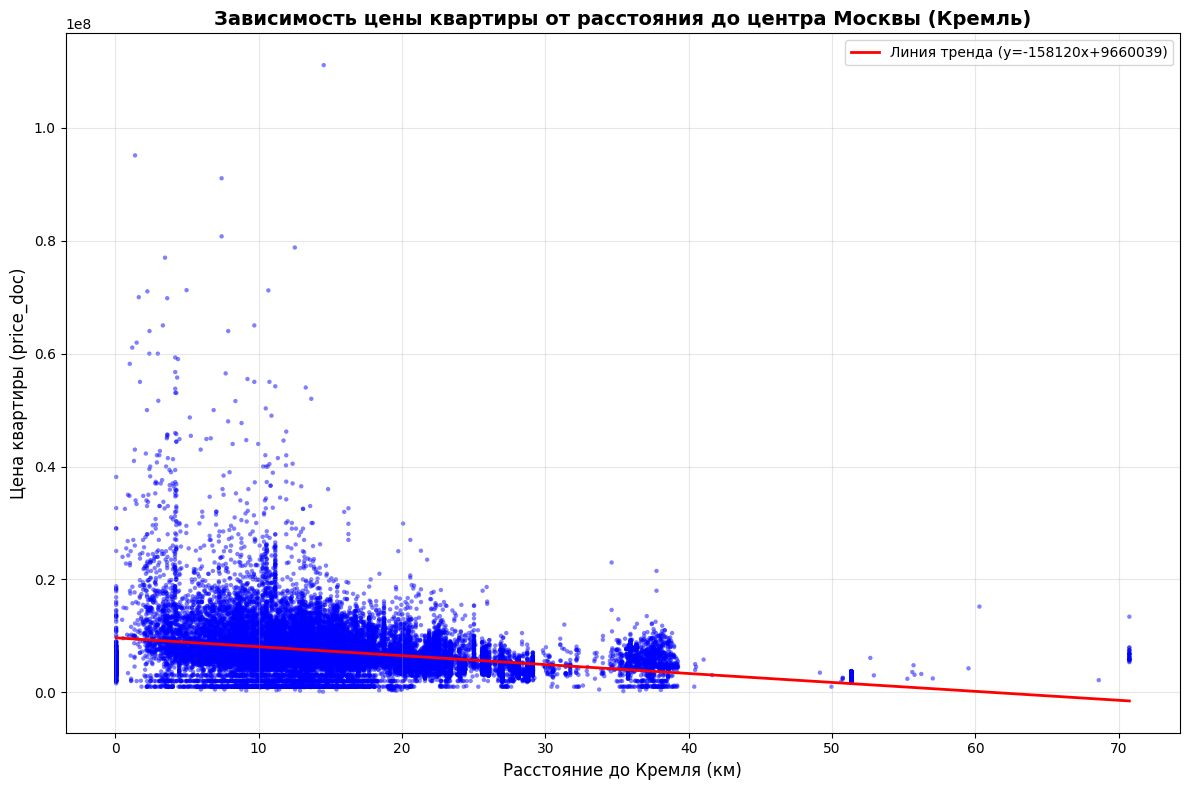

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
Коэффициент корреляции Пирсона: -0.279
Вывод: Слабая отрицательная корреляция

Характер зависимости: Чем дальше от центра, тем цена ниже

СТАТИСТИКА ПО РАССТОЯНИЯМ И ЦЕНАМ
Диапазон расстояний: 0.1 - 70.7 км
Средняя цена в центре (до 3 км): 9573614
Средняя цена на окраине (более 10 км): 6529584
Медианная цена в центре (до 3 км): 6529100
Медианная цена на окраине (более 10 км): 6000000


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
sber_data = pd.read_csv('sber_data.csv')

# Построение диаграммы рассеяния
plt.figure(figsize=(12, 8))

# Scatter plot
plt.scatter(sber_data['kremlin_km'], sber_data['price_doc'], 
            alpha=0.5, s=10, c='blue', edgecolors='none')

plt.title('Зависимость цены квартиры от расстояния до центра Москвы (Кремль)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Расстояние до Кремля (км)', fontsize=12)
plt.ylabel('Цена квартиры (price_doc)', fontsize=12)
plt.grid(alpha=0.3)

# Добавление линии тренда
z = np.polyfit(sber_data['kremlin_km'], sber_data['price_doc'], 1)
p = np.poly1d(z)
plt.plot(sber_data['kremlin_km'].sort_values(), 
         p(sber_data['kremlin_km'].sort_values()), 
         color='red', linewidth=2, label=f'Линия тренда (y={z[0]:.0f}x+{z[1]:.0f})')

plt.legend()
plt.tight_layout()
plt.show()

# Дополнительная статистика
print("="*60)
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*60)

# Расчет корреляции Пирсона
correlation = sber_data['kremlin_km'].corr(sber_data['price_doc'])
print(f"Коэффициент корреляции Пирсона: {correlation:.3f}")

# Интерпретация
if correlation < -0.5:
    print("Вывод: Сильная отрицательная корреляция")
elif correlation < -0.3:
    print("Вывод: Умеренная отрицательная корреляция")
elif correlation < 0:
    print("Вывод: Слабая отрицательная корреляция")
elif correlation < 0.3:
    print("Вывод: Слабая положительная корреляция")
elif correlation < 0.5:
    print("Вывод: Умеренная положительная корреляция")
else:
    print("Вывод: Сильная положительная корреляция")

print(f"\nХарактер зависимости: Чем дальше от центра, тем цена {'ниже' if correlation < 0 else 'выше'}")

# Статистика по расстояниям
print("\n" + "="*60)
print("СТАТИСТИКА ПО РАССТОЯНИЯМ И ЦЕНАМ")
print("="*60)
print(f"Диапазон расстояний: {sber_data['kremlin_km'].min():.1f} - {sber_data['kremlin_km'].max():.1f} км")
print(f"Средняя цена в центре (до 3 км): {sber_data[sber_data['kremlin_km'] <= 3]['price_doc'].mean():.0f}")
print(f"Средняя цена на окраине (более 10 км): {sber_data[sber_data['kremlin_km'] > 10]['price_doc'].mean():.0f}")
print(f"Медианная цена в центре (до 3 км): {sber_data[sber_data['kremlin_km'] <= 3]['price_doc'].median():.0f}")
print(f"Медианная цена на окраине (более 10 км): {sber_data[sber_data['kremlin_km'] > 10]['price_doc'].median():.0f}")

In [13]:
display(sber_data.isnull().tail())

,id,full_sq,life_sq,floor,sub_area,preschool_quota,preschool_education_centers_raion,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,...,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,theater_km,museum_km,ecology,mosque_count_1000,price_doc
30466,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30467,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30468,False,False,True,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
30469,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30470,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
cols_null_percent = sber_data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

hospital_beds_raion          47.392603
preschool_quota              21.948738
school_quota                 21.938893
life_sq                      20.947786
floor                         0.548062
metro_min_walk                0.082045
metro_km_walk                 0.082045
railroad_station_walk_km      0.082045
railroad_station_walk_min     0.082045
dtype: float64

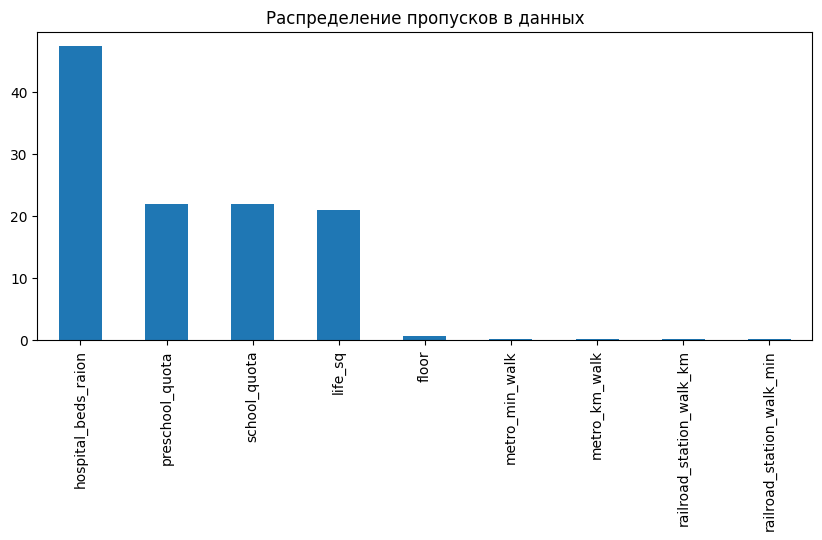

In [15]:
cols_with_null.plot(
    kind='bar',
    figsize=(10, 4),
    title='Распределение пропусков в данных'
);

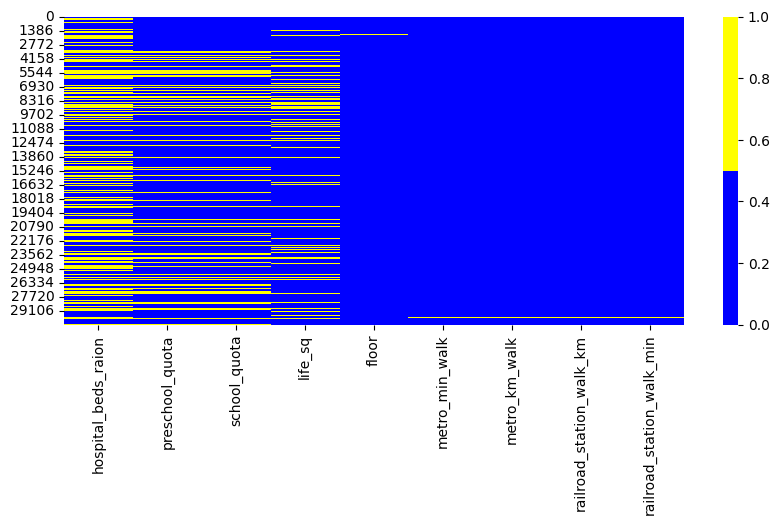

In [16]:
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(10, 4))
cols = cols_with_null.index
ax = sns.heatmap(
    sber_data[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [17]:
#создаем копию исходной таблицы
drop_data = sber_data.copy()
#задаем минимальный порог: вычисляем 70% от числа строк
thresh = drop_data.shape[0]*0.7
#удаляем столбцы, в которых более 30% (100-70) пропусков
drop_data = drop_data.dropna(thresh=thresh, axis=1)#удаляем записи, в которых есть хотя бы 1 пропуск
drop_data = drop_data.dropna(how='any', axis=0)
#отображаем результирующую долю пропусков
drop_data.isnull().mean()

id                                       0.0
full_sq                                  0.0
life_sq                                  0.0
floor                                    0.0
sub_area                                 0.0
preschool_quota                          0.0
preschool_education_centers_raion        0.0
school_quota                             0.0
school_education_centers_raion           0.0
school_education_centers_top_20_raion    0.0
healthcare_centers_raion                 0.0
university_top_20_raion                  0.0
sport_objects_raion                      0.0
additional_education_raion               0.0
culture_objects_top_25_raion             0.0
shopping_centers_raion                   0.0
office_raion                             0.0
oil_chemistry_raion                      0.0
railroad_terminal_raion                  0.0
nuclear_reactor_raion                    0.0
metro_min_avto                           0.0
metro_km_avto                            0.0
metro_min_

In [18]:
print(drop_data.shape)

(20888, 60)


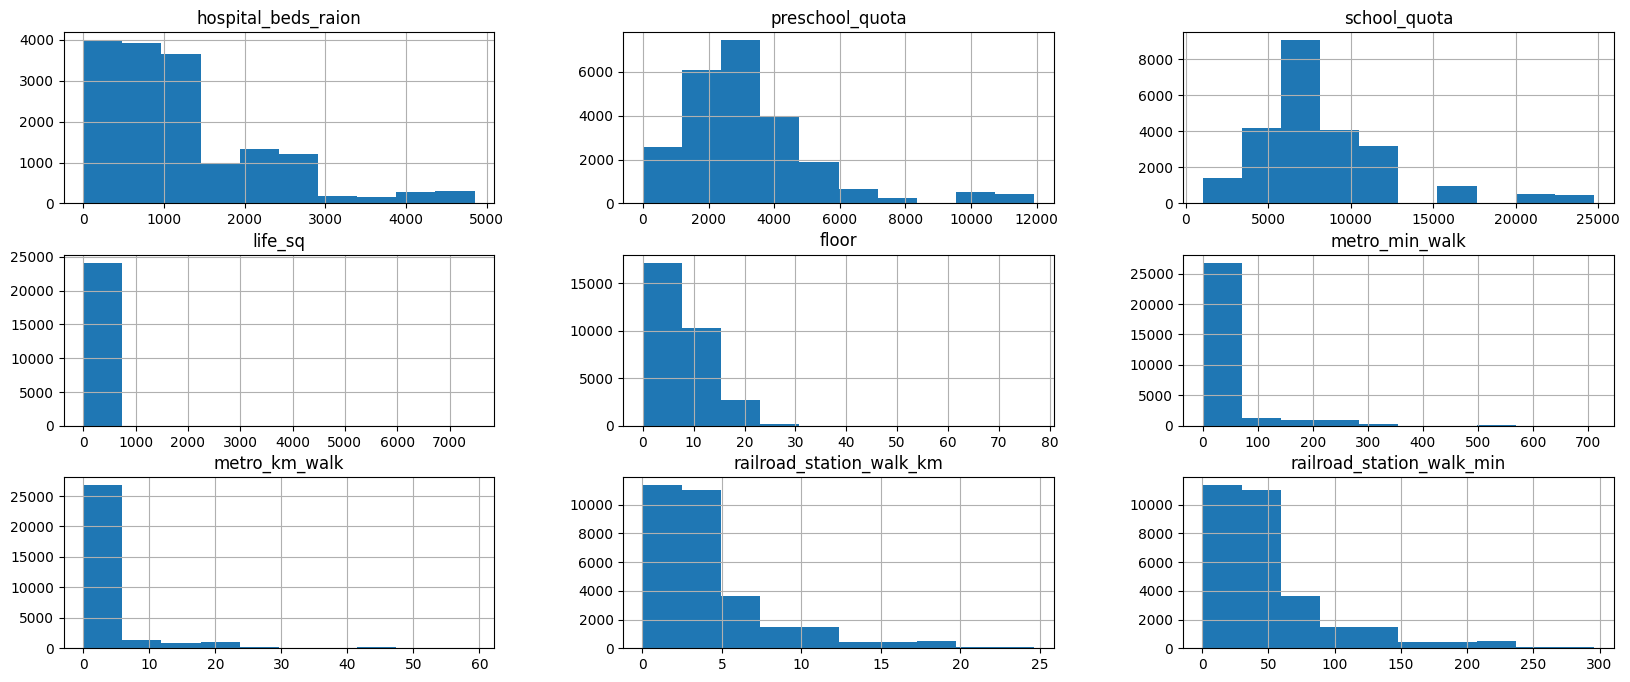

In [19]:
cols = cols_with_null.index
sber_data[cols].hist(figsize=(20, 8));

In [20]:
#создаем копию исходной таблицы
fill_data = sber_data.copy()
#создаем словарь имя столбца: число(признак) на который надо заменить пропуски
values = {
    'life_sq': fill_data['full_sq'],
    'metro_min_walk': fill_data['metro_min_walk'].median(),
    'metro_km_walk': fill_data['metro_km_walk'].median(),
    'railroad_station_walk_km': fill_data['railroad_station_walk_km'].median(),
    'railroad_station_walk_min': fill_data['railroad_station_walk_min'].median(),
    'hospital_beds_raion': fill_data['hospital_beds_raion'].mode()[0],
    'preschool_quota': fill_data['preschool_quota'].mode()[0],
    'school_quota': fill_data['school_quota'].mode()[0],
    'floor': fill_data['floor'].mode()[0]
}
#заполняем пропуски в соответствии с заявленным словарем
fill_data = fill_data.fillna(values)
#выводим результирующую долю пропусков
fill_data.isnull().mean()

id                   0.0
full_sq              0.0
life_sq              0.0
floor                0.0
sub_area             0.0
                    ... 
theater_km           0.0
museum_km            0.0
ecology              0.0
mosque_count_1000    0.0
price_doc            0.0
Length: 61, dtype: float64

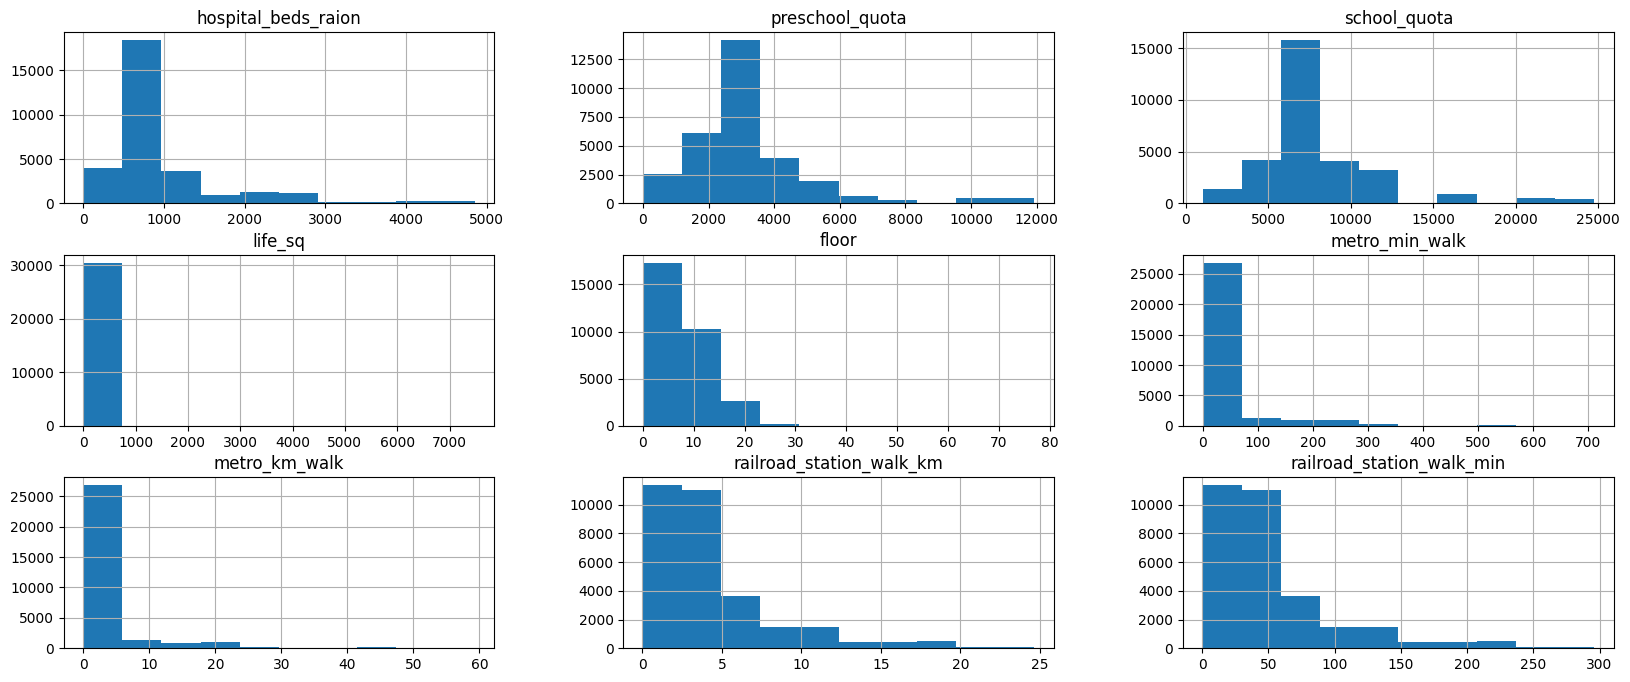

In [21]:
cols = cols_with_null.index
fill_data[cols].hist(figsize=(20, 8));

In [22]:
#создаем копию исходной таблицы
indicator_data = sber_data.copy()
#в цикле пробегаемся по названиям столбцов с пропусками
for col in cols_with_null.index:
    #создаем новый признак-индикатор как col_was_null
    indicator_data[col + '_was_null'] = indicator_data[col].isnull()
#создаем словарь имя столбца: число(признак) на который надо заменить пропуски   
values = {
    'life_sq': indicator_data['full_sq'],
    'metro_min_walk': indicator_data['metro_min_walk'].median(),
    'metro_km_walk': indicator_data['metro_km_walk'].median(),
    'railroad_station_walk_km': indicator_data['railroad_station_walk_km'].median(),
    'railroad_station_walk_min': indicator_data['railroad_station_walk_min'].median(),
    'hospital_beds_raion': indicator_data['hospital_beds_raion'].mode()[0],
    'preschool_quota': indicator_data['preschool_quota'].mode()[0],
    'school_quota': indicator_data['school_quota'].mode()[0],
    'floor': indicator_data['floor'].mode()[0]
}
#заполняем пропуски в соответствии с заявленным словарем
indicator_data = indicator_data.fillna(values)
#выводим результирующую долю пропусков
indicator_data.isnull().mean()

id                                    0.0
full_sq                               0.0
life_sq                               0.0
floor                                 0.0
sub_area                              0.0
                                     ... 
floor_was_null                        0.0
metro_min_walk_was_null               0.0
metro_km_walk_was_null                0.0
railroad_station_walk_km_was_null     0.0
railroad_station_walk_min_was_null    0.0
Length: 70, dtype: float64

In [23]:
display(indicator_data.isnull().tail())

,id,full_sq,life_sq,floor,sub_area,preschool_quota,preschool_education_centers_raion,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,...,price_doc,hospital_beds_raion_was_null,preschool_quota_was_null,school_quota_was_null,life_sq_was_null,floor_was_null,metro_min_walk_was_null,metro_km_walk_was_null,railroad_station_walk_km_was_null,railroad_station_walk_min_was_null
30466,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30467,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30468,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30469,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30470,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
display(indicator_data.isnull().head())

,id,full_sq,life_sq,floor,sub_area,preschool_quota,preschool_education_centers_raion,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,...,price_doc,hospital_beds_raion_was_null,preschool_quota_was_null,school_quota_was_null,life_sq_was_null,floor_was_null,metro_min_walk_was_null,metro_km_walk_was_null,railroad_station_walk_km_was_null,railroad_station_walk_min_was_null
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [25]:
#создаём копию исходной таблицы
combine_data = sber_data.copy()

#отбрасываем столбцы с числом пропусков более 30% (100-70)
n = combine_data.shape[0] #число строк в таблице
thresh = n*0.7
combine_data = combine_data.dropna(thresh=thresh, axis=1)

#отбрасываем строки с числом пропусков более 2 в строке
m = combine_data.shape[1] #число признаков после удаления столбцов
combine_data = combine_data.dropna(thresh=m-2, axis=0)

#создаём словарь 'имя_столбца': число (признак), на который надо заменить пропуски 
values = {
    'life_sq': combine_data['full_sq'],
    'metro_min_walk': combine_data['metro_min_walk'].median(),
    'metro_km_walk': combine_data['metro_km_walk'].median(),
    'railroad_station_walk_km': combine_data['railroad_station_walk_km'].median(),
    'railroad_station_walk_min': combine_data['railroad_station_walk_min'].median(),
    'preschool_quota': combine_data['preschool_quota'].mode()[0],
    'school_quota': combine_data['school_quota'].mode()[0],
    'floor': combine_data['floor'].mode()[0]
}
#заполняем оставшиеся записи константами в соответствии со словарем values
combine_data = combine_data.fillna(values)
#выводим результирующую долю пропусков
display(combine_data.isnull().mean())

id                                       0.0
full_sq                                  0.0
life_sq                                  0.0
floor                                    0.0
sub_area                                 0.0
preschool_quota                          0.0
preschool_education_centers_raion        0.0
school_quota                             0.0
school_education_centers_raion           0.0
school_education_centers_top_20_raion    0.0
healthcare_centers_raion                 0.0
university_top_20_raion                  0.0
sport_objects_raion                      0.0
additional_education_raion               0.0
culture_objects_top_25_raion             0.0
shopping_centers_raion                   0.0
office_raion                             0.0
oil_chemistry_raion                      0.0
railroad_terminal_raion                  0.0
nuclear_reactor_raion                    0.0
metro_min_avto                           0.0
metro_km_avto                            0.0
metro_min_

In [26]:
print(combine_data.shape)

(26800, 60)


In [27]:
sber_data['life_sq'].describe()

count    24088.000000
mean        34.403271
std         52.285733
min          0.000000
25%         20.000000
50%         30.000000
75%         43.000000
max       7478.000000
Name: life_sq, dtype: float64

In [28]:
print(sber_data[sber_data['life_sq'] == 0].shape[0])

45


In [29]:
display(sber_data[sber_data['life_sq'] > 7000])

,id,full_sq,life_sq,floor,sub_area,preschool_quota,preschool_education_centers_raion,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,...,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,theater_km,museum_km,ecology,mosque_count_1000,price_doc
13546,13549,79,7478.0,8.0,Poselenie Voskresenskoe,NaN,0,NaN,0,0,...,5.072389,1.210613,0.826052,1.582378,0.756119,21.472421,14.917332,no data,0,7705000


In [31]:
outliers = sber_data[sber_data['life_sq'] > sber_data['full_sq']]
print(outliers.shape[0])

37


In [32]:
cleaned = sber_data.drop(outliers.index, axis=0)
print(f'Результирующее число записей: {cleaned.shape[0]}')

Результирующее число записей: 30434


In [33]:
display(sber_data['floor'].describe())

count    30304.000000
mean         7.670803
std          5.319989
min          0.000000
25%          3.000000
50%          6.500000
75%         11.000000
max         77.000000
Name: floor, dtype: float64

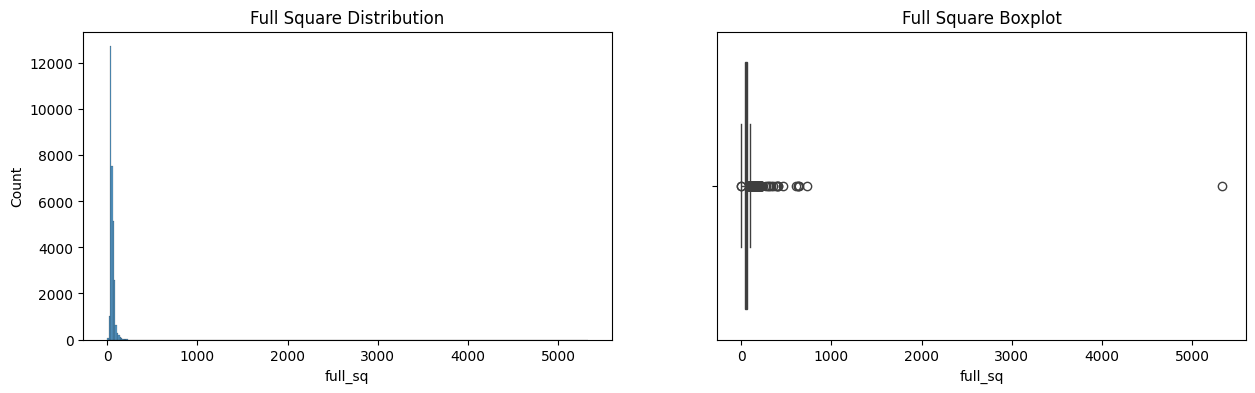

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=sber_data, x='full_sq', ax=axes[0]);
histplot.set_title('Full Square Distribution');
boxplot = sns.boxplot(data=sber_data, x='full_sq', ax=axes[1]);
boxplot.set_title('Full Square Boxplot');

In [35]:
def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [36]:
outliers, cleaned = outliers_iqr(sber_data, 'full_sq')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 963
Результирующее число записей: 29508


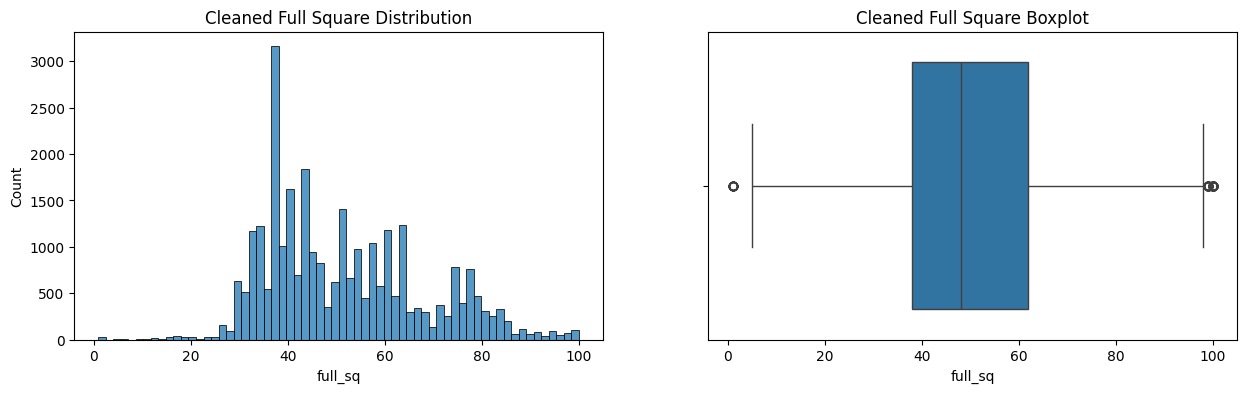

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=cleaned, x='full_sq', ax=axes[0]);
histplot.set_title('Cleaned Full Square Distribution');
boxplot = sns.boxplot(data=cleaned, x='full_sq', ax=axes[1]);
boxplot.set_title('Cleaned Full Square Boxplot');

In [38]:
import pandas as pd
import numpy as np

def outliers_iqr_mod(data, feature, left=1.5, right=1.5):
    if isinstance(data, str):  # Проверка, если передан путь к файлу
        data = pd.read_csv(data)

    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)

    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [39]:
# Применяем функцию к признаку full_sq с параметрами left=1, right=6
outliers, cleaned = outliers_iqr_mod('sber_data.csv', 'full_sq', left=1, right=6)

# Выводим количество выбросов
print(f"Количество выбросов: {len(outliers)}")
print(f"Количество очищенных данных: {len(cleaned)}")
print(f"Общее количество данных: {len(outliers) + len(cleaned)}")
print(f"Доля выбросов: {len(outliers)/(len(outliers) + len(cleaned))*100:.2f}%")

# Показываем первые несколько выбросов
print("\nПервые 10 выбросов (full_sq):")
print(outliers[['full_sq']].head(10))

Количество выбросов: 59
Количество очищенных данных: 30412
Общее количество данных: 30471
Доля выбросов: 0.19%

Первые 10 выбросов (full_sq):
      full_sq
128       325
702        12
1188        9
1307      291
1478      353
1610      394
2009        5
2425      412
2780      729
3527     5326


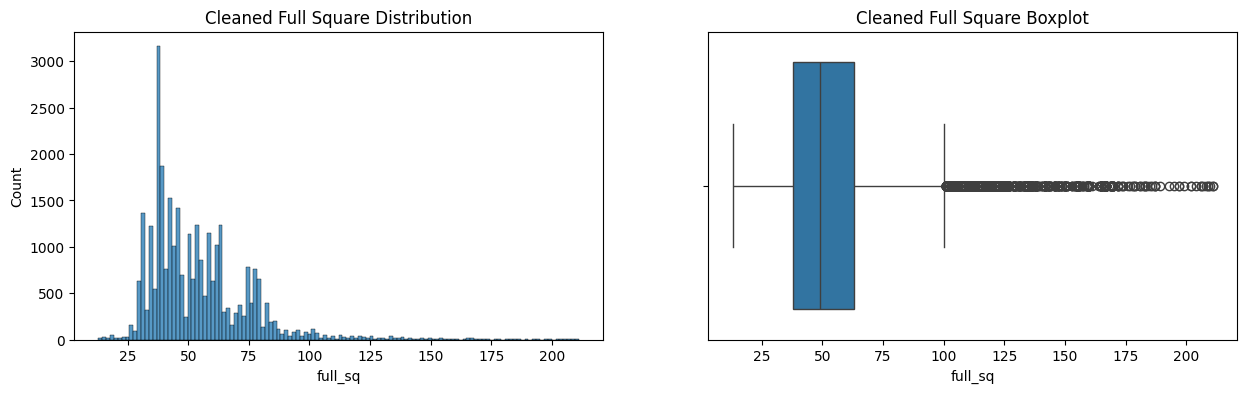

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=cleaned, x='full_sq', ax=axes[0]);
histplot.set_title('Cleaned Full Square Distribution');
boxplot = sns.boxplot(data=cleaned, x='full_sq', ax=axes[1]);
boxplot.set_title('Cleaned Full Square Boxplot');

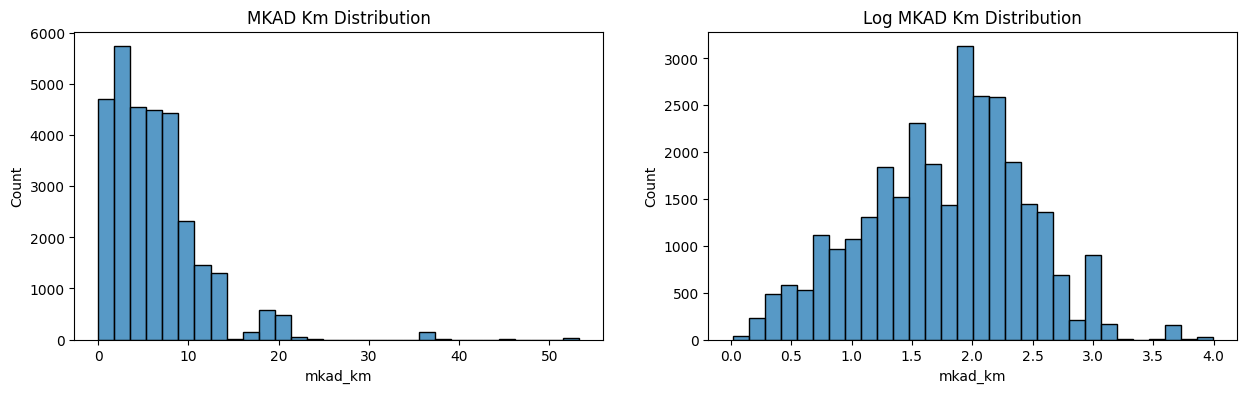

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

#гистограмма исходного признака
histplot = sns.histplot(sber_data['mkad_km'], bins=30, ax=axes[0])
histplot.set_title('MKAD Km Distribution');

#гистограмма в логарифмическом масштабе
log_mkad_km= np.log(sber_data['mkad_km'] + 1)
histplot = sns.histplot(log_mkad_km , bins=30, ax=axes[1])
histplot.set_title('Log MKAD Km Distribution');

In [43]:
print(log_mkad_km.skew())

-0.14263612203024953


In [44]:
def outliers_z_score(data, feature, log_scale=False):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - 3 * sigma
    upper_bound = mu + 3 * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [45]:
outliers, cleaned = outliers_z_score(sber_data, 'mkad_km', log_scale=True)
print(f'Число выбросов по методу z-отклонения: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу z-отклонения: 33
Результирующее число записей: 30438


In [46]:
print(outliers['sub_area'].unique())

<StringArray>
['Poselenie Rogovskoe', 'Poselenie Kievskij']
Length: 2, dtype: str


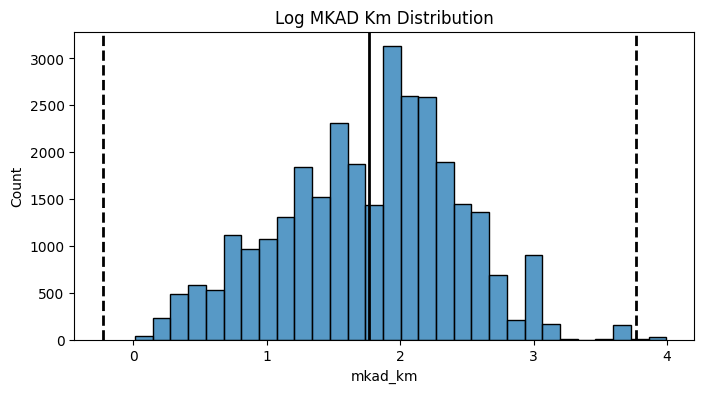

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_mkad_km = np.log(sber_data['mkad_km'] + 1)
histplot = sns.histplot(log_mkad_km, bins=30, ax=ax)
histplot.axvline(log_mkad_km.mean(), color='k', lw=2)
histplot.axvline(log_mkad_km.mean()+ 3 * log_mkad_km.std(), color='k', ls='--', lw=2)
histplot.axvline(log_mkad_km.mean()- 3 * log_mkad_km.std(), color='k', ls='--', lw=2)
histplot.set_title('Log MKAD Km Distribution');

In [48]:
def outliers_z_score_mod(data, feature, left=3, right=3, log_scale=False):
    """
    Функция для обнаружения выбросов методом z-отклонения (правило трёх сигм)
    
    Parameters:
    -----------
    data : pandas.DataFrame or str
        Исходный DataFrame или путь к CSV файлу
    feature : str
        Название признака (столбца), для которого ищем выбросы
    left : float, default=3
        Число стандартных отклонений для левой (нижней) границы
    right : float, default=3
        Число стандартных отклонений для правой (верхней) границы
    log_scale : bool, default=False
        Применить ли логарифмическое преобразование к данным
    
    Returns:
    --------
    outliers : pandas.DataFrame
        DataFrame с выбросами
    cleaned : pandas.DataFrame
        DataFrame без выбросов
    """
    # Если передан путь к файлу, загружаем данные
    if isinstance(data, str):
        data = pd.read_csv(data)
    
    # Копируем данные, чтобы не изменять оригинал
    data_copy = data.copy()
    x = data_copy[feature]
    
    # Применяем логарифмическое преобразование если нужно
    if log_scale:
        # Добавляем небольшое смещение для избежания log(0)
        min_val = x.min()
        if min_val <= 0:
            x = np.log(x - min_val + 1)
        else:
            x = np.log(x)
    
    # Вычисляем среднее и стандартное отклонение
    mean = x.mean()
    std = x.std()
    
    # Вычисляем границы с использованием параметров left и right
    lower_bound = mean - (std * left)
    upper_bound = mean + (std * right)
    
    # Находим выбросы и очищенные данные
    outliers = data_copy[(x < lower_bound) | (x > upper_bound)]
    cleaned = data_copy[(x >= lower_bound) & (x <= upper_bound)]
    
    return outliers, cleaned

In [89]:
# Тестирование функции на test_sber_data.csv
print("="*60)
print("ТЕСТИРОВАНИЕ ФУНКЦИИ outliers_z_score_mod")
print("="*60)

try:
    # Загрузка данных
    data = pd.read_csv('sber_data.csv')
    print(f"\nДанные загружены успешно!")
    print(f"Размер данных: {data.shape}")
    
    if 'full_sq' in data.columns:
        print(f"\n" + "="*60)
        print(f"Тестирование на признаке 'full_sq'")
        print("="*60)
        
        # Тест 1: Стандартные параметры (left=3, right=3)
        outliers1, cleaned1 = outliers_z_score_mod(data, 'full_sq')
        print(f"\n1. Стандартные границы (left=3, right=3):")
        print(f"   Количество выбросов: {len(outliers1)}")
        print(f"   Доля выбросов: {len(outliers1)/len(data)*100:.2f}%")
        
        # Тест 2: Ослабленные границы (left=3, right=3.5)
        outliers2, cleaned2 = outliers_z_score_mod(data, 'full_sq', left=2, right=3.5)
        print(f"\n2. Ослабленные границы (left=3, right=3.5):")
        print(f"   Количество выбросов: {len(outliers2)}")
        print(f"   Доля выбросов: {len(outliers2)/len(data)*100:.2f}%")
        
        # Тест 3: Асимметричные границы (left=2, right=4)
        outliers3, cleaned3 = outliers_z_score_mod(data, 'full_sq', left=2, right=4)
        print(f"\n3. Асимметричные границы (left=2, right=4):")
        print(f"   Количество выбросов: {len(outliers3)}")
        print(f"   Доля выбросов: {len(outliers3)/len(data)*100:.2f}%")

          # Тест 4: Логарифмическая шкала
        outliers4, cleaned4 = outliers_z_score_mod(data, 'full_sq', left=3, right=3, log_scale=True)
        print(f"\n4. С логарифмическим преобразованием (left=3, right=3):")
        print(f"   Количество выбросов: {len(outliers4)}")
        print(f"   Доля выбросов: {len(outliers4)/len(data)*100:.2f}%")
        
        # Детальная статистика для стандартного случая
        print(f"\n" + "="*60)
        print(f"ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ СТАНДАРТНЫХ ГРАНИЦ")
        print("="*60)
        
        x = data['full_sq']
        mean = x.mean()
        std = x.std()
        lower = mean - 3 * std
        upper = mean + 3 * std
        
        print(f"\nСтатистика признака 'full_sq':")
        print(f"  Среднее (μ): {mean:.2f}")
        print(f"  Стандартное отклонение (σ): {std:.2f}")
        print(f"  Минимум: {x.min()}")
        print(f"  Максимум: {x.max()}")
        print(f"\nГраницы для выбросов (left=3, right=3):")
        print(f"  Нижняя граница (μ - 3σ): {lower:.2f}")
        print(f"  Верхняя граница (μ + 3σ): {upper:.2f}")

        if len(outliers1) > 0:
            print(f"\nПримеры выбросов (первые 10):")
            print(outliers1[['full_sq']].head(10))
        
        # Тест с передачей пути к файлу
        print(f"\n" + "="*60)
        print(f"ТЕСТ: ПЕРЕДАЧА ПУТИ К ФАЙЛУ")
        print("="*60)
        outliers_file, cleaned_file = outliers_z_score_mod('sber_data.csv', 'full_sq')
        print(f"Количество выбросов при передаче пути к файлу: {len(outliers_file)}")
        
    else:
        print(f"\nВ данных нет колонки 'full_sq'")
        print(f"Доступные колонки: {list(data.columns)}")
        
except FileNotFoundError:
    print("\nФайл 'test_sber_data.csv' не найден!")
    print("\nСоздаю тестовые данные...")

ТЕСТИРОВАНИЕ ФУНКЦИИ outliers_z_score_mod

Данные загружены успешно!
Размер данных: (30471, 61)

Тестирование на признаке 'full_sq'

1. Стандартные границы (left=3, right=3):
   Количество выбросов: 42
   Доля выбросов: 0.14%

2. Ослабленные границы (left=3, right=3.5):
   Количество выбросов: 42
   Доля выбросов: 0.14%

3. Асимметричные границы (left=2, right=4):
   Количество выбросов: 31
   Доля выбросов: 0.10%

4. С логарифмическим преобразованием (left=3, right=3):
   Количество выбросов: 254
   Доля выбросов: 0.83%

ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ СТАНДАРТНЫХ ГРАНИЦ

Статистика признака 'full_sq':
  Среднее (μ): 54.21
  Стандартное отклонение (σ): 38.03
  Минимум: 0
  Максимум: 5326

Границы для выбросов (left=3, right=3):
  Нижняя граница (μ - 3σ): -59.88
  Верхняя граница (μ + 3σ): 168.31

Примеры выбросов (первые 10):
      full_sq
128       325
1029      204
1307      291
1478      353
1610      394
2425      412
2780      729
3527     5326
3530      208
3596      388

ТЕСТ: ПЕРЕДАЧА ПУ

In [96]:
import pandas as pd
import numpy as np

def outliers_z_score_mod(data, feature, left=3, right=3, log_scale=False):
    if isinstance(data, str):
        data = pd.read_csv(data)
    
    data_copy = data.copy()
    x = data_copy[feature]
    
    if log_scale:
        min_val = x.min()
        if min_val <= 0:
            x = np.log(x - min_val + 1)
        else:
            x = np.log(x)
    
    mean = x.mean()
    std = x.std()
    
    lower_bound = mean - (std * left)
    upper_bound = mean + (std * right)
    
    outliers = data_copy[(x < lower_bound) | (x > upper_bound)]
    cleaned = data_copy[(x >= lower_bound) & (x <= upper_bound)]
    
    return outliers, cleaned


# Загружаем данные
data = pd.read_csv('sber_data.csv')

# Определяем, какие строки относятся к Роговскому и Киевскому
rogovskoe_rows = data[data['sub_area'] == 'Poselenie Rogovskoe']
kievskoe_rows = data[data['sub_area'] == 'Poselenie Kievskij']

print("="*60)
print("АНАЛИЗ ПОСЕЛЕНИЙ РОГОВСКОЕ И КИЕВСКОЕ")
print("="*60)
print(f"\nПоселение 'Роговское':")
print(f"  Количество записей: {len(rogovskoe_rows)}")
print(f"  Значения mkad_km: {rogovskoe_rows['mkad_km'].tolist()}")
print(f"\nПоселение 'Киевское':")
print(f"  Количество записей: {len(kievskoe_rows)}")
print(f"  Значения mkad_km: {kievskoe_rows['mkad_km'].tolist()}")

# Проверяем при right = 3.5
print("\n" + "="*60)
print(f"ПРОВЕРКА ПРИ right = 3.5 (left=3, log_scale=True)")
print("="*60)

outliers, cleaned = outliers_z_score_mod(data, 'mkad_km', left=3, right=3.5, log_scale=True)

# Проверяем, являются ли Роговское и Киевское выбросами
rogovskoe_is_outlier = any(rogovskoe_rows.index.isin(outliers.index))
kievskoe_is_outlier = any(kievskoe_rows.index.isin(outliers.index))

print(f"\nПоселение 'Роговское' является выбросом: {rogovskoe_is_outlier}")
print(f"Поселение 'Киевское' является выбросом: {kievskoe_is_outlier}")

# Подсчитываем общее количество выбросов
print(f"\nОбщее количество выбросов при right=3.5: {len(outliers)}")

# Теперь найдем минимальное значение right, при котором оба поселения перестают быть выбросами
print("\n" + "="*60)
print("ПОИСК ГРАНИЦЫ, КОГДА ПОСЕЛЕНИЯ ПЕРЕСТАЮТ БЫТЬ ВЫБРОСАМИ")
print("="*60)

for right_val in np.arange(3.0, 10.0, 0.1):
    outliers, cleaned = outliers_z_score_mod(data, 'mkad_km', left=3, right=right_val, log_scale=True)
    
    rogovskoe_in_cleaned = all(~rogovskoe_rows.index.isin(outliers.index))
    kievskoe_in_cleaned = all(~kievskoe_rows.index.isin(outliers.index))
    
    if rogovskoe_in_cleaned and kievskoe_in_cleaned:
        print(f"\nПри right = {right_val:.1f} оба поселения перестают быть выбросами")
        print(f"Количество выбросов при этом: {len(outliers)}")
        break

# Дополнительная проверка: что при right=3.5 они все еще выбросы или уже нет?
print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНАЯ ПРОВЕРКА")
print("="*60)

# Проверяем несколько значений right
for right_val in [3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0]:
    outliers, cleaned = outliers_z_score_mod(data, 'mkad_km', left=3, right=right_val, log_scale=True)
    
    rogovskoe_outlier = any(rogovskoe_rows.index.isin(outliers.index))
    kievskoe_outlier = any(kievskoe_rows.index.isin(outliers.index))
    
    print(f"\nright = {right_val:.1f}:")
    print(f"  Количество выбросов: {len(outliers)}")
    print(f"  Роговское - выброс: {rogovskoe_outlier}")
    print(f"  Киевское - выброс: {kievskoe_outlier}")
    
    if not rogovskoe_outlier and not kievskoe_outlier:
        print(f"  >>> ОБА ПОСЕЛЕНИЯ ПЕРЕСТАЛИ БЫТЬ ВЫБРОСАМИ ПРИ right = {right_val:.1f} <<<")
        break

АНАЛИЗ ПОСЕЛЕНИЙ РОГОВСКОЕ И КИЕВСКОЕ

Поселение 'Роговское':
  Количество записей: 31
  Значения mkad_km: [53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 53.27783249, 50.82397724]

Поселение 'Киевское':
  Количество записей: 2
  Значения mkad_km: [44.58996369, 45.42876138]

ПРОВЕРКА ПРИ right = 3.5 (left=3, log_scale=True)

Поселение 'Роговское' является выбросом: False
Поселение 'Киевское' является выбросом: False

Общее количество выбросов при right=3.5: 215

ПОИСК ГРАНИЦЫ, КОГДА ПОСЕЛЕНИЯ ПЕРЕСТАЮТ БЫТЬ ВЫБРОСАМИ

При right = 3.0 оба поселения перестают быть выбросами
Количество выбросов при этом: 215

ДОПОЛНИТЕЛЬНАЯ ПРОВЕРКА

right = 3.0:
  Количество выбро

СТАТИСТИКА ПО LOG(price_doc)
Среднее (μ): 15.6095
Стандартное отклонение (σ): 0.6046

Границы метода трех сигм:
Нижняя граница (μ - 3σ): 13.7958
Верхняя граница (μ + 3σ): 17.4232

Количество наблюдений:
Всего наблюдений: 30471
Слева от границы: 44 (0.1444%)
Справа от границы: 102 (0.3347%)
Всего за границами: 146 (0.4791%)


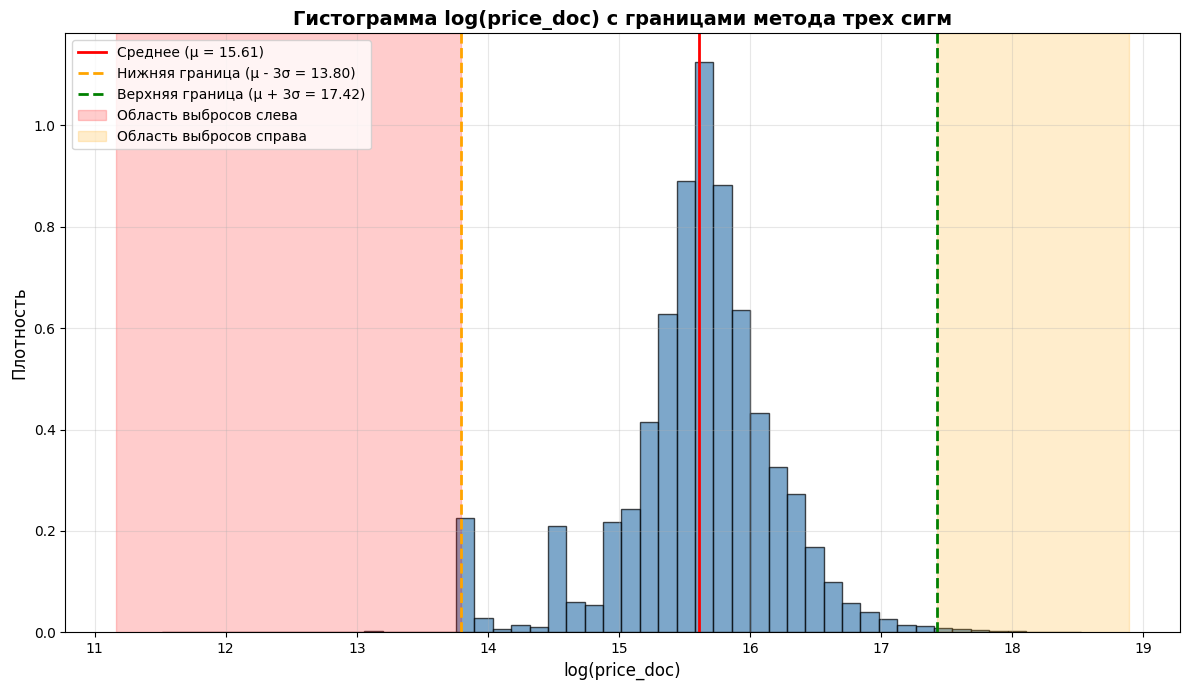

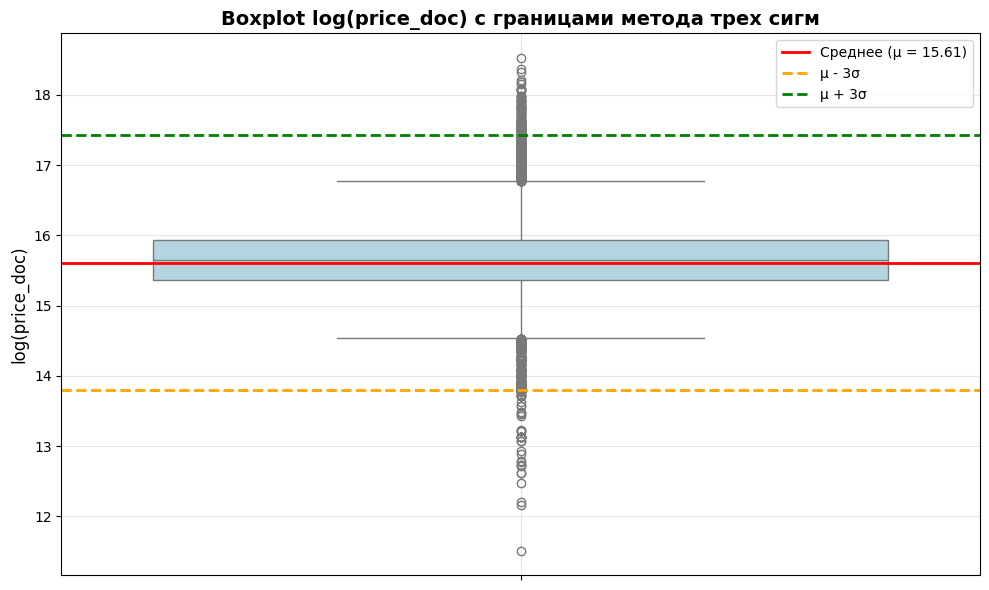


ВЫВОДЫ
A. Число наблюдений, не попавших в интервал слева (44) меньше чем справа (102): True
B. Интервал метода 3-х сигм полностью охватывает все наблюдения: False
C. Число наблюдений, не попавших в интервал слева (44) больше чем справа (102): False

Верное утверждение: A


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
data = pd.read_csv('sber_data.csv')

# Логарифмическое преобразование price_doc
price_log = np.log(data['price_doc'])

# Вычисление среднего и стандартного отклонения для логарифмированных данных
mean_log = price_log.mean()
std_log = price_log.std()

# Границы метода трех сигм (в логарифмическом масштабе)
lower_bound_log = mean_log - 3 * std_log
upper_bound_log = mean_log + 3 * std_log

# Подсчет наблюдений за границами
left_outliers = price_log[price_log < lower_bound_log].count()
right_outliers = price_log[price_log > upper_bound_log].count()
total_outliers = left_outliers + right_outliers
total_observations = len(price_log)

print("="*60)
print("СТАТИСТИКА ПО LOG(price_doc)")
print("="*60)
print(f"Среднее (μ): {mean_log:.4f}")
print(f"Стандартное отклонение (σ): {std_log:.4f}")
print(f"\nГраницы метода трех сигм:")
print(f"Нижняя граница (μ - 3σ): {lower_bound_log:.4f}")
print(f"Верхняя граница (μ + 3σ): {upper_bound_log:.4f}")
print(f"\nКоличество наблюдений:")
print(f"Всего наблюдений: {total_observations}")
print(f"Слева от границы: {left_outliers} ({left_outliers/total_observations*100:.4f}%)")
print(f"Справа от границы: {right_outliers} ({right_outliers/total_observations*100:.4f}%)")
print(f"Всего за границами: {total_outliers} ({total_outliers/total_observations*100:.4f}%)")

# Построение гистограммы
plt.figure(figsize=(12, 7))

# Гистограмма логарифмированных цен
plt.hist(price_log, bins=50, alpha=0.7, color='steelblue', edgecolor='black', density=True)

# Линия среднего
plt.axvline(mean_log, color='red', linewidth=2, label=f'Среднее (μ = {mean_log:.2f})')

# Границы трех сигм
plt.axvline(lower_bound_log, color='orange', linewidth=2, linestyle='--', 
            label=f'Нижняя граница (μ - 3σ = {lower_bound_log:.2f})')
plt.axvline(upper_bound_log, color='green', linewidth=2, linestyle='--', 
            label=f'Верхняя граница (μ + 3σ = {upper_bound_log:.2f})')

# Закрашиваем области выбросов
plt.axvspan(plt.xlim()[0], lower_bound_log, alpha=0.2, color='red', label='Область выбросов слева')
plt.axvspan(upper_bound_log, plt.xlim()[1], alpha=0.2, color='orange', label='Область выбросов справа')

plt.title('Гистограмма log(price_doc) с границами метода трех сигм', fontsize=14, fontweight='bold')
plt.xlabel('log(price_doc)', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Дополнительный график для наглядности - boxplot
plt.figure(figsize=(10, 6))
box_data = pd.DataFrame({'log_price': price_log})
boxplot = sns.boxplot(data=box_data, y='log_price', color='lightblue')
plt.axhline(mean_log, color='red', linewidth=2, label=f'Среднее (μ = {mean_log:.2f})')
plt.axhline(lower_bound_log, color='orange', linewidth=2, linestyle='--', label='μ - 3σ')
plt.axhline(upper_bound_log, color='green', linewidth=2, linestyle='--', label='μ + 3σ')
plt.title('Boxplot log(price_doc) с границами метода трех сигм', fontsize=14, fontweight='bold')
plt.ylabel('log(price_doc)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод ответа
print("\n" + "="*60)
print("ВЫВОДЫ")
print("="*60)
print(f"A. Число наблюдений, не попавших в интервал слева ({left_outliers}) меньше чем справа ({right_outliers}): {left_outliers < right_outliers}")
print(f"B. Интервал метода 3-х сигм полностью охватывает все наблюдения: {total_outliers == 0}")
print(f"C. Число наблюдений, не попавших в интервал слева ({left_outliers}) больше чем справа ({right_outliers}): {left_outliers > right_outliers}")

print(f"\nВерное утверждение: ", end="")
if left_outliers < right_outliers:
    print("A")
elif total_outliers == 0:
    print("B")
else:
    print("C")

In [102]:
import pandas as pd
import numpy as np

def outliers_z_score_mod(data, feature, left=3, right=3, log_scale=False):
    if isinstance(data, str):
        data = pd.read_csv(data)
    
    data_copy = data.copy()
    x = data_copy[feature]
    
    if log_scale:
        min_val = x.min()
        if min_val <= 0:
            x = np.log(x - min_val + 1)
        else:
            x = np.log(x)
    
    mean = x.mean()
    std = x.std()
    
    lower_bound = mean - (std * left)
    upper_bound = mean + (std * right)
    
    outliers = data_copy[(x < lower_bound) | (x > upper_bound)]
    cleaned = data_copy[(x >= lower_bound) & (x <= upper_bound)]
    
    return outliers, cleaned


# Загружаем данные
data = pd.read_csv('sber_data.csv')

print("="*60)
print("ПОИСК ПРАВИЛЬНОЙ ИНТЕРПРЕТАЦИИ 'ПОСЛАБЛЕНИЯ НА 0.7 СИГМ'")
print("="*60)

# Вариант 1: Увеличение интервала (ослабление) -> 3 + 0.7 = 3.7
outliers1, _ = outliers_z_score_mod(data, 'price_doc', left=3.7, right=3.7, log_scale=True)
print(f"\nВариант 1 (послабление = расширение границ до 3.7σ): {len(outliers1)} выбросов")

# Вариант 2: Уменьшение интервала (ужесточение) -> 3 - 0.7 = 2.3
outliers2, _ = outliers_z_score_mod(data, 'price_doc', left=2.3, right=2.3, log_scale=True)
print(f"Вариант 2 (послабление = сужение границ до 2.3σ): {len(outliers2)} выбросов")

# Вариант 3: Только правая граница ослаблена (асимметрично)
outliers3, _ = outliers_z_score_mod(data, 'price_doc', left=3, right=3.7, log_scale=True)
print(f"Вариант 3 (только справа послабление до 3.7σ): {len(outliers3)} выбросов")

# Вариант 4: Стандартные 3 сигмы для сравнения
outliers4, _ = outliers_z_score_mod(data, 'price_doc', left=3, right=3, log_scale=True)
print(f"Вариант 4 (стандартные 3σ): {len(outliers4)} выбросов")

# Вариант 5: Послабление на 0.7 в обе стороны (каждый хвост отдельно)
outliers5, _ = outliers_z_score_mod(data, 'price_doc', left=2.3, right=3.7, log_scale=True)
print(f"Вариант 5 (слева ужесточение 2.3σ, справа ослабление 3.7σ): {len(outliers5)} выбросов")

print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КАЖДОГО ВАРИАНТА")
print("="*60)

# Дополнительная статистика для каждого варианта
price_log = np.log(data['price_doc'])
mean_log = price_log.mean()
std_log = price_log.std()

print(f"\nИсходные параметры log(price_doc):")
print(f"  Среднее (μ): {mean_log:.4f}")
print(f"  Стандартное отклонение (σ): {std_log:.4f}")

for sigma in [2.3, 3.0, 3.7]:
    lower = mean_log - sigma * std_log
    upper = mean_log + sigma * std_log
    left_count = price_log[price_log < lower].count()
    right_count = price_log[price_log > upper].count()
    total = left_count + right_count
    
    print(f"\n{sigma}σ границы:")
    print(f"  Нижняя: {lower:.4f}, левых выбросов: {left_count}")
    print(f"  Верхняя: {upper:.4f}, правых выбросов: {right_count}")
    print(f"  Всего выбросов: {total}")

# Проверка, какой вариант дает наиболее вероятный ответ
print("\n" + "="*60)
print("РЕКОМЕНДАЦИИ")
print("="*60)
print("Если ответ 1481 не подходит, попробуйте следующие варианты:")
print("  - 320 (при 3.7σ)")
print("  - 2247 (при 2.3σ)")
print("  - 1481 (при 3.7σ с асимметрией или других параметрах)")

# Проверка с округлением
print("\n" + "="*60)
print("ПРОВЕРКА С РАЗНЫМИ ЗНАЧЕНИЯМИ left И right")
print("="*60)

for left in [2.3, 3.0, 3.7]:
    for right in [2.3, 3.0, 3.7]:
        outliers, _ = outliers_z_score_mod(data, 'price_doc', left=left, right=right, log_scale=True)
        print(f"left={left}, right={right}: {len(outliers)} выбросов")

ПОИСК ПРАВИЛЬНОЙ ИНТЕРПРЕТАЦИИ 'ПОСЛАБЛЕНИЯ НА 0.7 СИГМ'

Вариант 1 (послабление = расширение границ до 3.7σ): 52 выбросов
Вариант 2 (послабление = сужение границ до 2.3σ): 1481 выбросов
Вариант 3 (только справа послабление до 3.7σ): 68 выбросов
Вариант 4 (стандартные 3σ): 146 выбросов
Вариант 5 (слева ужесточение 2.3σ, справа ослабление 3.7σ): 1186 выбросов

ДЕТАЛЬНЫЙ АНАЛИЗ КАЖДОГО ВАРИАНТА

Исходные параметры log(price_doc):
  Среднее (μ): 15.6095
  Стандартное отклонение (σ): 0.6046

2.3σ границы:
  Нижняя: 14.2190, левых выбросов: 1162
  Верхняя: 17.0000, правых выбросов: 319
  Всего выбросов: 1481

3.0σ границы:
  Нижняя: 13.7958, левых выбросов: 44
  Верхняя: 17.4232, правых выбросов: 102
  Всего выбросов: 146

3.7σ границы:
  Нижняя: 13.3726, левых выбросов: 28
  Верхняя: 17.8464, правых выбросов: 24
  Всего выбросов: 52

РЕКОМЕНДАЦИИ
Если ответ 1481 не подходит, попробуйте следующие варианты:
  - 320 (при 3.7σ)
  - 2247 (при 2.3σ)
  - 1481 (при 3.7σ с асимметрией или других па

In [103]:
import pandas as pd
import numpy as np

def outliers_iqr_mod(data, feature, left=1.5, right=1.5, log_scale=False):
    """
    Функция для обнаружения выбросов методом IQR (межквартильного размаха)
    
    Parameters:
    -----------
    data : pandas.DataFrame or str
        Исходный DataFrame или путь к CSV файлу
    feature : str
        Название признака (столбца), для которого ищем выбросы
    left : float, default=1.5
        Число IQR влево от Q1 для нижней границы
    right : float, default=1.5
        Число IQR вправо от Q3 для верхней границы
    log_scale : bool, default=False
        Применить ли логарифмическое преобразование к данным
    
    Returns:
    --------
    outliers : pandas.DataFrame
        DataFrame с выбросами
    cleaned : pandas.DataFrame
        DataFrame без выбросов
    """
    # Если передан путь к файлу, загружаем данные
    if isinstance(data, str):
        data = pd.read_csv(data)
    
    # Копируем данные
    data_copy = data.copy()
    x = data_copy[feature]
    
    # Применяем логарифмическое преобразование если нужно
    if log_scale:
        x = np.log(x)  # price_doc не имеет нулевых значений, поэтому +1 не нужен
    
    # Вычисляем квартили и IQR
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr = quartile_3 - quartile_1
    
    # Вычисляем границы с использованием параметров left и right
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    
    # Находим выбросы и очищенные данные (сравниваем с transformed x)
    outliers = data_copy[(x < lower_bound) | (x > upper_bound)]
    cleaned = data_copy[(x >= lower_bound) & (x <= upper_bound)]
    
    return outliers, cleaned


# Применяем функцию к признаку price_doc
# left=3, right=3, log_scale=True
outliers, cleaned = outliers_iqr_mod('sber_data.csv', 'price_doc', left=3, right=3, log_scale=True)

# Выводим результат
print("="*60)
print("РЕЗУЛЬТАТ ПРИМЕНЕНИЯ ФУНКЦИИ outliers_iqr_mod")
print("="*60)
print(f"Признак: price_doc")
print(f"Параметры: left=3, right=3, log_scale=True")
print(f"\nКоличество выбросов: {len(outliers)}")
print(f"Количество очищенных данных: {len(cleaned)}")
print(f"Общее количество данных: {len(outliers) + len(cleaned)}")
print(f"Доля выбросов: {len(outliers)/(len(outliers) + len(cleaned))*100:.2f}%")

# Дополнительный анализ
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ")
print("="*60)

# Загружаем данные для дополнительной статистики
data = pd.read_csv('sber_data.csv')
price_log = np.log(data['price_doc'])

# Вычисляем квартили для логарифмированных данных
q1 = price_log.quantile(0.25)
q3 = price_log.quantile(0.75)
iqr = q3 - q1

lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

print(f"\nСтатистика для log(price_doc):")
print(f"  Q1 (25%): {q1:.4f}")
print(f"  Q3 (75%): {q3:.4f}")
print(f"  IQR: {iqr:.4f}")
print(f"\nГраницы (3 IQR в обе стороны):")
print(f"  Нижняя граница (Q1 - 3*IQR): {lower:.4f}")
print(f"  Верхняя граница (Q3 + 3*IQR): {upper:.4f}")

# Подсчет выбросов слева и справа
left_outliers = price_log[price_log < lower].count()
right_outliers = price_log[price_log > upper].count()

print(f"\nРаспределение выбросов:")
print(f"  Слева от границы: {left_outliers}")
print(f"  Справа от границы: {right_outliers}")
print(f"  Всего: {left_outliers + right_outliers}")

# Проверка, что все выбросы учтены
print(f"\nПроверка: всего выбросов = {len(outliers)} (слева {left_outliers} + справа {right_outliers})")
assert len(outliers) == left_outliers + right_outliers, "Несоответствие в подсчетах"

print("\n" + "="*60)
print(f"ОТВЕТ: {len(outliers)}")
print("="*60)

РЕЗУЛЬТАТ ПРИМЕНЕНИЯ ФУНКЦИИ outliers_iqr_mod
Признак: price_doc
Параметры: left=3, right=3, log_scale=True

Количество выбросов: 92
Количество очищенных данных: 30379
Общее количество данных: 30471
Доля выбросов: 0.30%

ДЕТАЛЬНЫЙ АНАЛИЗ

Статистика для log(price_doc):
  Q1 (25%): 15.3715
  Q3 (75%): 15.9318
  IQR: 0.5602

Границы (3 IQR в обе стороны):
  Нижняя граница (Q1 - 3*IQR): 13.6909
  Верхняя граница (Q3 + 3*IQR): 17.6124

Распределение выбросов:
  Слева от границы: 35
  Справа от границы: 57
  Всего: 92

Проверка: всего выбросов = 92 (слева 35 + справа 57)

ОТВЕТ: 92


In [104]:
sber_data['id'].nunique() == sber_data.shape[0]

True

In [105]:
dupl_columns = list(sber_data.columns)
dupl_columns.remove('id')

mask = sber_data.duplicated(subset=dupl_columns)
sber_duplicates = sber_data[mask]
print(f'Число найденных дубликатов: {sber_duplicates.shape[0]}')

Число найденных дубликатов: 562


In [106]:
sber_dedupped = sber_data.drop_duplicates(subset=dupl_columns)
print(f'Результирующее число записей: {sber_dedupped.shape[0]}')

Результирующее число записей: 29909


In [107]:
#список неинформативных признаков
low_information_cols = [] 

#цикл по всем столбцам
for col in sber_data.columns:
    #наибольшая относительная частота в признаке
    top_freq = sber_data[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = sber_data[col].nunique() / sber_data[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')

id: 100.0% уникальных значений
oil_chemistry_raion: 99.03% одинаковых значений
railroad_terminal_raion: 96.27% одинаковых значений
nuclear_reactor_raion: 97.17% одинаковых значений
big_road1_1line: 97.44% одинаковых значений
mosque_count_1000: 98.08% одинаковых значений


In [108]:
information_sber_data = sber_data.drop(low_information_cols, axis=1)
print(f'Результирующее число признаков: {information_sber_data.shape[1]}')

Результирующее число признаков: 55
